## SubGraphs With LLM 

**Subgraph:** We'll have a subgraph that calculates the discount for a customer based on their purchase amount.

**Parent Graph:** We'll generate a personalized discount report using the result from the subgraph, which is then enhanced by invoking an LLM to provide a personalized message.

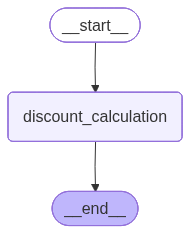

In [7]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START
from langchain_aws import ChatBedrockConverse
from langchain_core.messages import HumanMessage

# LLM setup for personalized report generation
llm = ChatBedrockConverse(
    model_id="amazon.nova-lite-v1:0",  # AWS Bedrock model ID
    region_name="us-east-1",           # AWS region
    temperature=0.7,                   # More creative output
    max_tokens=100                     # Generate a message with sufficient detail
)

# --- Subgraph definition ---

class PurchaseState(TypedDict):
    purchase_amount: float
    discount: float

# Discount calculation logic (subgraph)
def discount_calculation(state: PurchaseState):
    purchase_amount = state["purchase_amount"]
    
    if purchase_amount >= 1000:
        discount = 20  # 20% discount
    elif purchase_amount >= 500:
        discount = 10  # 10% discount
    elif purchase_amount >= 200:
        discount = 5  # 5% discount
    else:
        discount = 0  # No discount
    
    return {"discount": discount}

# Build the subgraph to calculate discount
subgraph_builder = StateGraph(PurchaseState)
subgraph_builder.add_node("discount_calculation", discount_calculation)
subgraph_builder.add_edge(START, "discount_calculation")
discount_subgraph = subgraph_builder.compile()
discount_subgraph

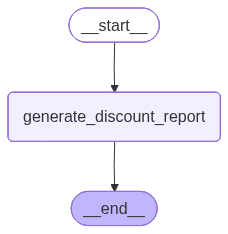

In [8]:
# --- Parent graph definition ---

class CustomerState(TypedDict):
    name: str
    purchase_amount: float
    discount: float
    discount_report: str


# Function to generate personalized report (parent graph)
def generate_discount_report(state: CustomerState):
    # Call the discount subgraph with the customer's purchase amount
    discount_output = discount_subgraph.invoke({"purchase_amount": state["purchase_amount"]})
    discount = discount_output["discount"]
    
    # Generate a basic discount report
    discount_report = f"{state['name']} is eligible for a {discount}% discount on their purchase."

    # Generate a personalized message from LLM
    message_input = [{"role": "user", "content": f"Based on the discount, generate a personalized message for {state['name']} who got a {discount}% discount."}]
    response = llm.invoke([HumanMessage(content=message_input[0]["content"])])
    
    # Append LLM response to the report
    discount_report += " " + response.content

    # Return complete state with report and discount
    return {"discount": discount, "discount_report": discount_report}

# Build the parent graph to generate the discount report
parent_builder = StateGraph(CustomerState)
parent_builder.add_node("generate_discount_report", generate_discount_report)
parent_builder.add_edge(START, "generate_discount_report")
discount_report_graph = parent_builder.compile()
discount_report_graph

In [9]:
# --- Sample invocation ---
customer_state = {"name": "Raj", "purchase_amount": 750}  # Customer with $750 purchase
report = discount_report_graph.invoke(customer_state)

# Print the generated report
print(report)

{'name': 'Raj', 'purchase_amount': 750, 'discount': 10, 'discount_report': "Raj is eligible for a 10% discount on their purchase. Subject: Enjoy Your 10% Savings, Raj!\n\nHi Raj,\n\nWe hope you're doing well! We wanted to let you know that you've received a special 10% discount on your recent purchase. We truly value your loyalty and wanted to show our appreciation.\n\nThank you for choosing us – we look forward to serving you again soon!\n\nBest regards,  \n[Your Company Name] Team\n\n---\n\nFeel free to customize this message further to match your brand’s tone and"}
